# **Laboratorio 7, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

In [49]:
import requests
import librosa
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import interpolate
import scipy.integrate as integrate
import pandas as pd

In [26]:
#Subimos la nota musical.
uploaded=files.upload()

Saving Nota_CM_piano.mp3 to Nota_CM_piano.mp3


In [50]:
signal,sr=librosa.load("Nota_CM_piano.mp3",sr=None)

## **1) Do the FFT using scipy and Numpy rutines (see notebook)**

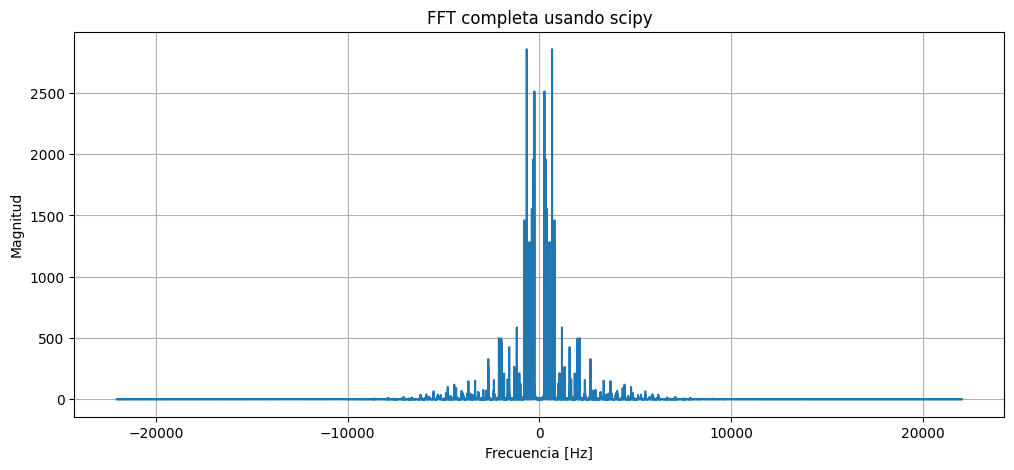

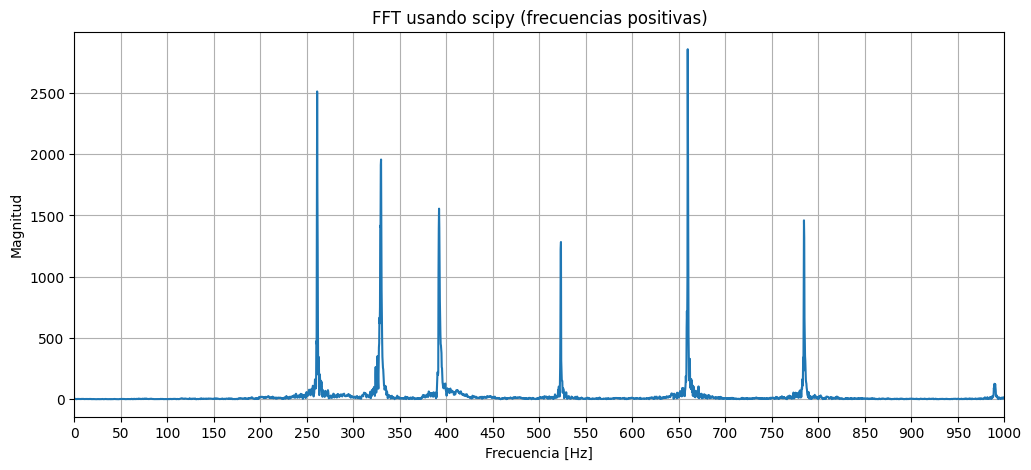

In [51]:
#Usando scipy

N=len(signal)          #Tenemos N muestras.
T=1/sr                 #Tiempo entre muestras


#Realizamos la transformada rápida de Fourier y encontramos las frecuencias asociadas.
Y=fft(signal)
freq=fftfreq(N,T)

#Magnitud de la FFT.
magnitude=np.abs(Y)

#Analizaremos las frecuencias y magnitudes positivas.
positive=freq>=0         #Esta función nos da los indices donde la frecuencia es positiva.
freq_pos=freq[positive]
magnitude_pos=magnitude[positive]


#Graficamos el espectro completo.
plt.figure(figsize=(12,5))
plt.plot(freq, magnitude)
plt.title("FFT completa usando scipy")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid()
plt.show()

#Graficamos solo frecuencias.
plt.figure(figsize=(12,5))
plt.plot(freq_pos, magnitude_pos)
plt.title("FFT usando scipy (frecuencias positivas)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0,1000)
plt.xticks(np.arange(0,1001,50))
plt.grid()
plt.show()

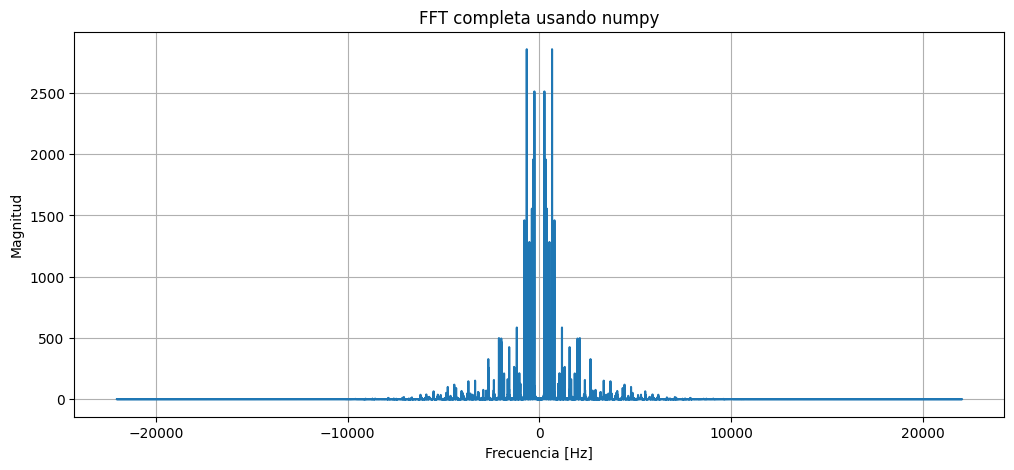

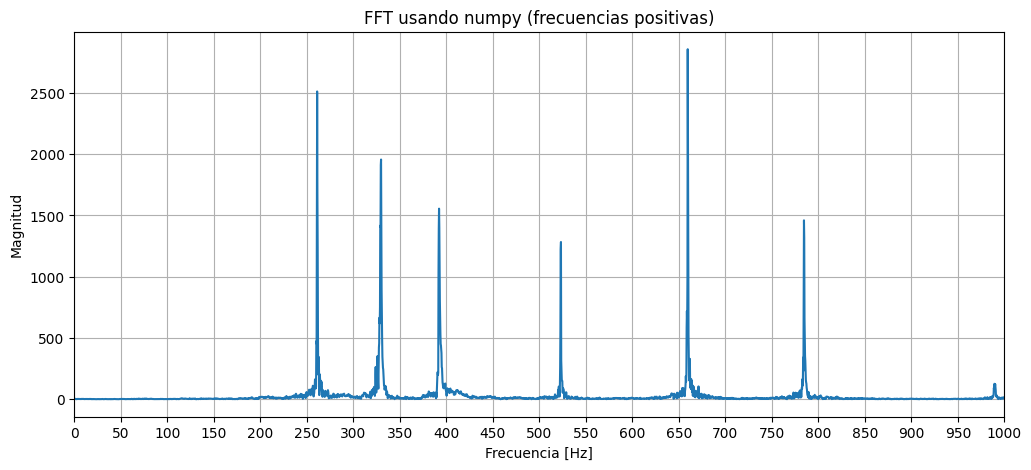

In [52]:
#Usando numpy

N=len(signal)        #Número de muestras.

#Realizamos la transformada de Fourier y encontramos las frecuencias asociadas.
Y=np.fft.fft(signal)
freq=np.fft.fftfreq(N,d=1/sr)

#Magnitud de la FFT.
magnitude=np.abs(Y)

#Separamos las frecuencias positivas.
positive=freq>=0
freq_pos=freq[positive]
magnitude_pos=magnitude[positive]

#Grafica del espectro completo.
plt.figure(figsize=(12,5))
plt.plot(freq,magnitude)
plt.title("FFT completa usando numpy")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid()
plt.show()

#Grafica con solo las frecuencias positivas.
plt.figure(figsize=(12,5))
plt.plot(freq_pos,magnitude_pos)
plt.title("FFT usando numpy (frecuencias positivas)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0,1000)
plt.xticks(np.arange(0,1001,50))
plt.grid()
plt.show()

Vemos que ambas librerias dan un muy buen resultado, son sencillas de usar y se hace de manera rapida. Se pueden apreciar perfectamente las frecuencias asociadas al Do mayor

Do (C) = 261.63 Hz

Mi (E) = 329.63 Hz

Sol (G) = 392.00 Hz

## **2) Used the rutine created in class FT(x,y). Modify it and do the FT to the signal. Do you get the same results?**

In [53]:
def g(t,w):
  return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

def FT(x,y):
  f_interp=interpolate.interp1d(x,y,kind="cubic",fill_value="extrapolate")
  ft=lambda t: f_interp(t)

  t=np.linspace(x.min(),x.max(),400)

  #Buscamos entre 0 y 1000 Hz, rango que analizamos antes.
  w=np.linspace(0,1000,2000)

  df=[]

  for i in range(len(w)):

    # Parte real
    ARew=integrate.quad(lambda t:ft(t)*g(t,w[i]).real,t.min(),t.max())[0]

    # Parte imaginaria
    AImw=integrate.quad(lambda t:ft(t)*g(t,w[i]).imag,t.min(),t.max())[0]

    # Magnitud
    AMP=np.sqrt(ARew**2+AImw**2)

    # Fase
    ANG=np.arctan2(AImw,ARew)

    # Guardar resultados
    df.append([w[i], ARew, AImw, AMP, ANG])

  df=pd.DataFrame(df,columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])

  return df

In [39]:
# Tiempo total de la señal
T=len(signal)/sr

# Vector temporal
x=np.linspace(0,T,len(signal))

#Hacemos la transformada.
df = FT(x,signal)


#Graficamos
#plt.figure(figsize=(12,5))
#plt.plot(df["w"], df["AMP"])
#plt.title("Transformada de Fourier usando FT(x,y)")
#plt.xlabel("Frecuencia [Hz]")
#plt.ylabel("Amplitud")
#plt.xlim(0,1000)
#plt.xticks(np.arange(0,1001,50))
#plt.grid()
#plt.show()

/tmp/ipykernel_1923/2670190641.py:18: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew=integrate.quad(lambda t:ft(t)*g(t,w[i]).real,t.min(),t.max())[0]
/tmp/ipykernel_1923/2670190641.py:21: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  AImw=integrate.quad(lambda t:ft(t)*g(t,w[i]).imag,t.min(),t.max())[0]
/tmp/ipykernel_1923/2670190641.py:21: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw=integrate.quad(lambda t:ft(t)*g(t,w[i]).imag,t.min(),t.max())[0]
/tmp/ipykernel_1923/2670190641.py:18: IntegrationWarning:

KeyboardInterrupt: 

In [54]:
#Usando como base la función definida en clase tengo problemas en la integracion.
#Entonces voy a hacer una nueva función integrando ahora numericamente.

T=len(signal)/sr
x=np.linspace(0,T,len(signal))

dt=x[1]-x[0]

def FT_new(x,y):

  #Frecuencias de interés
  w=np.linspace(0,1000,2000)

  AMP=[]

  for wi in w:
    #Integral discreta
    Fw=np.sum(y*g(x,wi))*dt

    AMP.append(np.abs(Fw))

  return w,np.array(AMP)

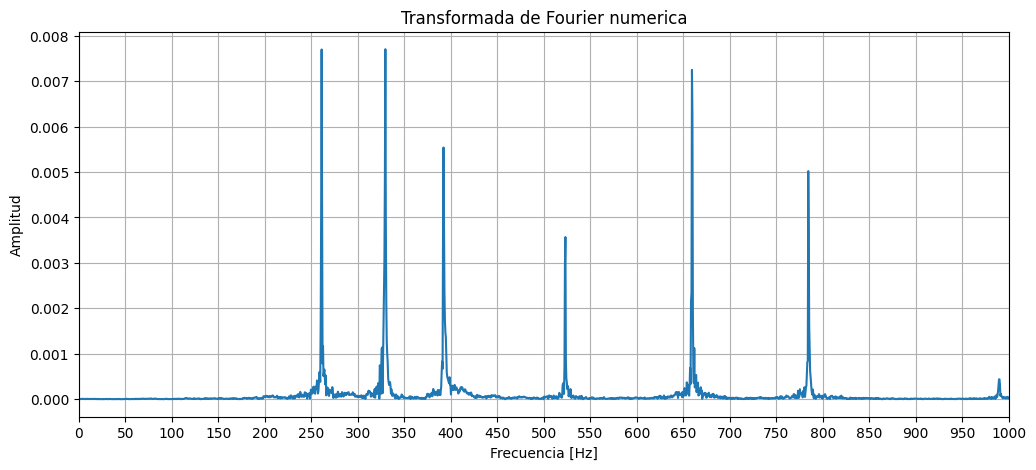

In [55]:
w,AMP=FT_new(x,signal)

plt.figure(figsize=(12,5))
plt.plot(w,AMP)
plt.title("Transformada de Fourier numerica")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.xlim(0,1000)
plt.xticks(np.arange(0,1001,50))
plt.grid()
plt.show()

Como podemos ver, esta función que definimos es bastante util, el resultado es similar a los resultados obtenidos usando las librerias. La magnitud cambia, pero es cuestión de normalización. Por la integración, este metodo se demora mucho mas que al usar las librerias, pero es un metodo muy util.